# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
import spacy
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [ ]:
carpeta = 'C:/Users/Desktop/caso_01'

textos_bloque_sur = []
textos_bloque_caribe = []
textos_bloque_noroccidental = []
textos_bloque_occidental = []
textos_bloque_comandocc = []
textos_bloque_oriental = []
textos_bloque_magdalenam = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()
            archivo_lower = archivo.lower()
            if 'bloque sur' in archivo_lower:
                textos_bloque_sur.append((archivo, contenido))
            elif 'bloque caribe' in archivo_lower:
                textos_bloque_caribe.append((archivo, contenido))
            elif 'bloque noroccidental' in archivo_lower or 'bloque noroccident' in archivo_lower:
                textos_bloque_noroccidental.append((archivo, contenido))
            elif 'bloque occidental' in archivo_lower or 'comando conjunto de' in archivo_lower:
                textos_bloque_occidental.append((archivo, contenido))
            elif 'comando conjunto central' in archivo_lower:
                textos_bloque_comandocc.append((archivo, contenido))
            elif 'bloque oriental' in archivo_lower:
                textos_bloque_oriental.append((archivo, contenido))
            elif 'bloque magdalena' in archivo_lower:
                textos_bloque_magdalenam.append((archivo, contenido))
            else:
                textos_otros.append((archivo, contenido))


# Lista de archivos para agregar manualmente al bloque oriental
archivos_extra_caribe= [
    "Audiencia observaciones de víctimas a diligencia Versiones Voluntarias del Bloqu_yVBatob06lQ.txt",
    "Audiencia observaciones de víctimas a diligencia Versiones Voluntarias del Bloqu_5eyxaJPQofw.txt",
    "Audiencia observaciones de víctimas a diligencia Versiones Voluntarias del Bloqu_lP2TqEkyupc.txt",
    "Caso 01 Audiencia de observaciones a diligencia de versiones voluntarias de Bloq_Uoc3eo1Rj7E.txt"]

# Agregar manualmente si no fueron clasificados ya
for nombre_archivo in archivos_extra_caribe:
    ruta_archivo = os.path.join(carpeta, nombre_archivo)
    if os.path.exists(ruta_archivo):
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()
        if not any(nombre_archivo == a for a, _ in textos_bloque_caribe):
            textos_bloque_caribe.append((nombre_archivo, contenido))

texto_bloque_sur = ' '.join([contenido for _, contenido in textos_bloque_sur])
texto_bloque_caribe = ' '.join([contenido for _, contenido in textos_bloque_caribe])
texto_bloque_noroccidental = ' '.join([contenido for _, contenido in textos_bloque_noroccidental])
texto_bloque_occidental = ' '.join([contenido for _, contenido in textos_bloque_occidental])
texto_comandocc = ' '.join([contenido for _, contenido in textos_bloque_comandocc])
texto_bloque_oriental = ' '.join([contenido for _, contenido in textos_bloque_oriental])
texto_bloque_magdalenam = ' '.join([contenido for _, contenido in textos_bloque_magdalenam])

print(f"Archivos de b. sur: {len(textos_bloque_sur)}")
print(f"Archivos de b. caribe: {len(textos_bloque_caribe)}")
print(f"Archivos de b. noroccidental: {len(textos_bloque_noroccidental)}")
print(f"Archivos de b. occidental: {len(textos_bloque_occidental)}")
print(f"Archivos de b. comandocc: {len(textos_bloque_comandocc )}")
print(f"Archivos de b. oriental: {len(textos_bloque_oriental)}")
print(f"Archivos de b. magdalena: {len(textos_bloque_magdalenam)}")


Archivos de b. sur: 21
Archivos de b. caribe: 10
Archivos de b. noroccidental: 10
Archivos de b. occidental: 5
Archivos de b. comandocc: 3
Archivos de b. oriental: 16
Archivos de b. magdalena: 4


In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    tokens = word_tokenize(texto)
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)

def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas

def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado


def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)


In [ ]:
#Realizar una primera lematización
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)
textos = {
    'Bloque Sur': texto_bloque_sur,
    'Bloque Caribe': texto_bloque_caribe,
    'Bloque Noroccidental': texto_bloque_noroccidental,
    'Bloque Occidental': texto_bloque_occidental,
    'Comando Conjunto Central': texto_comandocc,
    'Bloque Oriental': texto_bloque_oriental,
    'Bloque Magdalena Medio': texto_bloque_magdalenam
    }

textos_lematizados = {}

for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

texto_sur_lem = textos_lematizados['Bloque Sur']
texto_caribe_lem = textos_lematizados['Bloque Caribe']
texto_noroccidental_lem = textos_lematizados['Bloque Noroccidental']
texto_occidental_lem = textos_lematizados['Bloque Occidental']
texto_comandocc_lem = textos_lematizados['Comando Conjunto Central']
texto_oriental_lem = textos_lematizados['Bloque Oriental']
texto_magdalenam_lem = textos_lematizados['Bloque Magdalena Medio']

#Eliminar palabras cortas:
texto_sur_final = eliminar_palabras_cortas(texto_sur_lem)
texto_caribe_final = eliminar_palabras_cortas(texto_caribe_lem)
texto_noroccidental_final = eliminar_palabras_cortas(texto_noroccidental_lem)
texto_occidental_final = eliminar_palabras_cortas(texto_occidental_lem)
texto_comandocc_final = eliminar_palabras_cortas(texto_comandocc_lem)
texto_oriental_final = eliminar_palabras_cortas(texto_oriental_lem)
texto_magdalenam_final = eliminar_palabras_cortas(texto_magdalenam_lem)


##tokenizar
textos = {
    'Bloque Sur': texto_sur_final ,
    'Bloque Caribe': texto_caribe_final,
    'Bloque Noroccidental': texto_noroccidental_final,
    'Bloque Occidental': texto_occidental_final,
    'Comando Conjunto Central': texto_comandocc_final,
    'Bloque Oriental': texto_oriental_final,
    'Bloque Magdalena Medio': texto_magdalenam_final
    }
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# palabras que NO deben lematizarse
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
##reconstruir los textos:
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ['Bloque Sur' , 'Bloque Caribe', 'Bloque Noroccidental', 'Bloque Occidental','Comando Conjunto Central', 'Bloque Oriental', 'Bloque Magdalena Medio']}

# Lematizaciones personalizadas por caso:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_01.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

textos_finales_dicc = {}
for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final


# **GENERAR SKIPGRAMAS**

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))


ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]


ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ----------------     Generar skipgramas  ---------------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas}

In [ ]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Bloque Sur':


,Skipgrama,Frecuencia
0,bloque sur,496
1,version voluntario,490
2,antiguo bloque,252
3,antiguo farc,212
4,victima secuestro,208
5,antiguo sur,206
6,extinto farc,198
7,observacion version,183
8,demandar reconocimiento,182
9,observacion victima,178



Top 10 skipgramas en 'Bloque Caribe':


,Skipgrama,Frecuencia
0,version voluntario,163
1,bloque caribe,102
2,reconocimiento victima,84
3,frente farc,66
4,victima secuestro,65
5,victima compareciente,58
6,ministerio publico,58
7,antiguo bloque,58
8,version compareciente,57
9,reconocimiento compareciente,57



Top 10 skipgramas en 'Bloque Noroccidental':


...

,Skipgrama,Frecuencia
0,comando conjunto,109
1,comando central,97
2,conjunto central,92
3,version voluntario,81
4,version compareciente,42
5,observacion version,36
6,victima secuestro,36
7,unidad victima,35
8,reconocimiento victima,34
9,compareciente comando,33



Top 10 skipgramas en 'Bloque Oriental':


,Skipgrama,Frecuencia
0,version voluntario,357
1,bloque oriental,262
2,extinto farc,199
3,version compareciente,184
4,demandar reconocimiento,171
5,desaparicion forzar,170
6,reconocimiento compareciente,170
7,reconocimiento victima,161
8,compareciente victima,142
9,compareciente antiguo,139



Top 10 skipgramas en 'Bloque Magdalena Medio':


,Skipgrama,Frecuencia
0,magdalena medio,86
1,version voluntario,77
2,bloque magdalena,63
3,bloque medio,63
4,compareciente antiguo,44
5,extinto farc,41
6,ministerio publico,40
7,demandar reconocimiento,38
8,john alexander,38
9,reconocimiento victima,36


# **Análisis descriptivo**

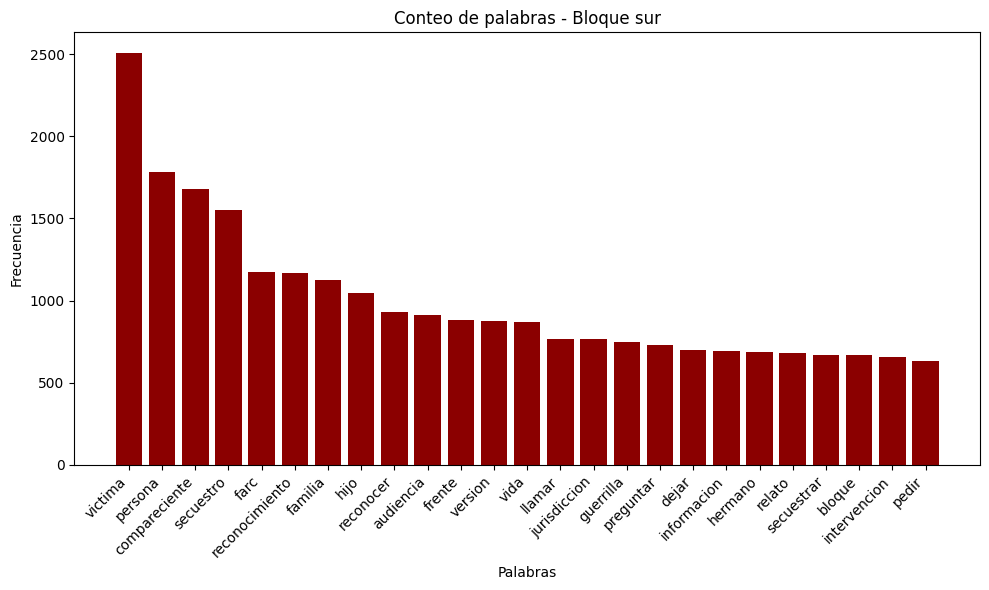

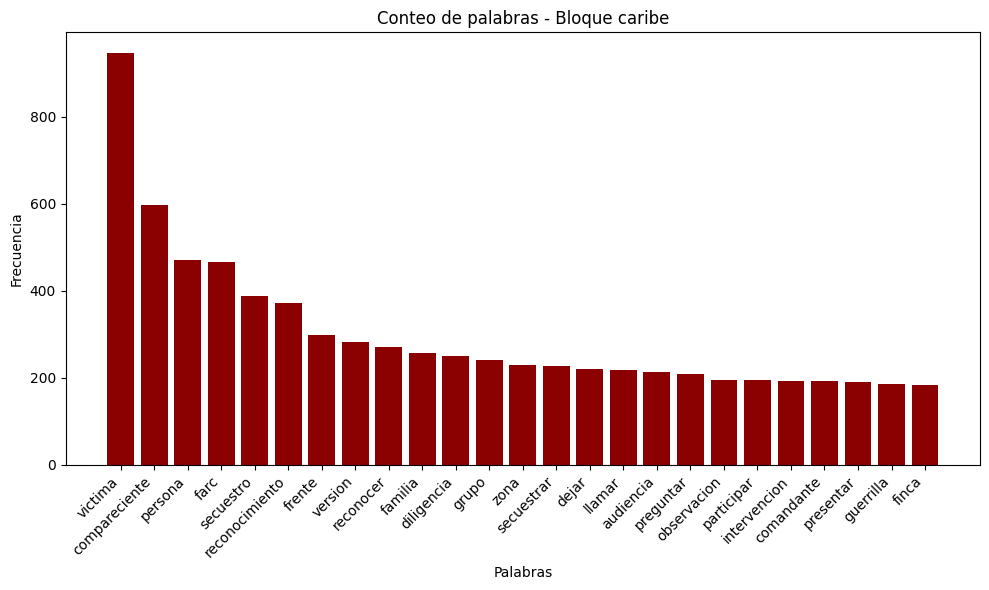

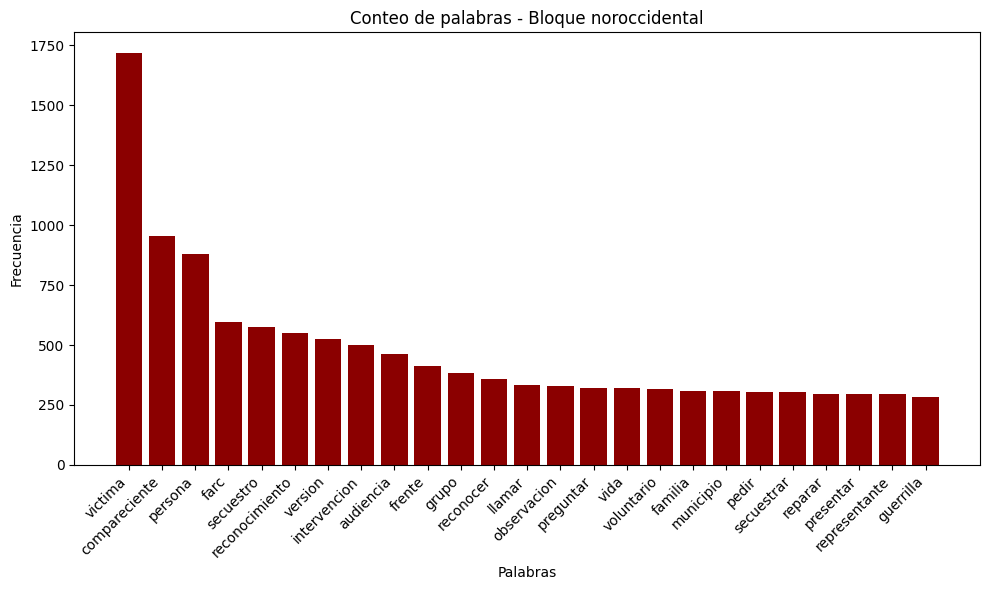

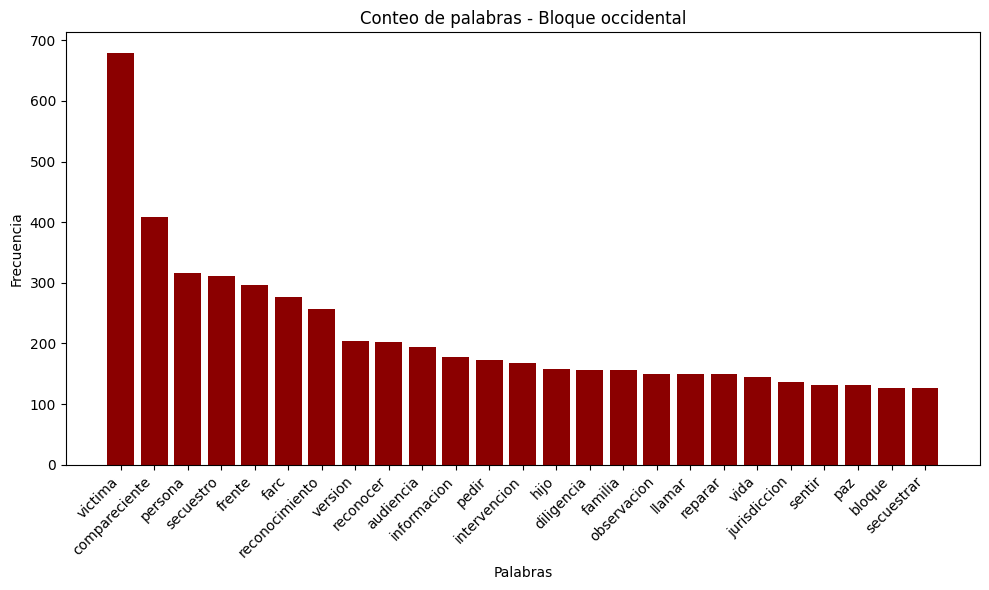

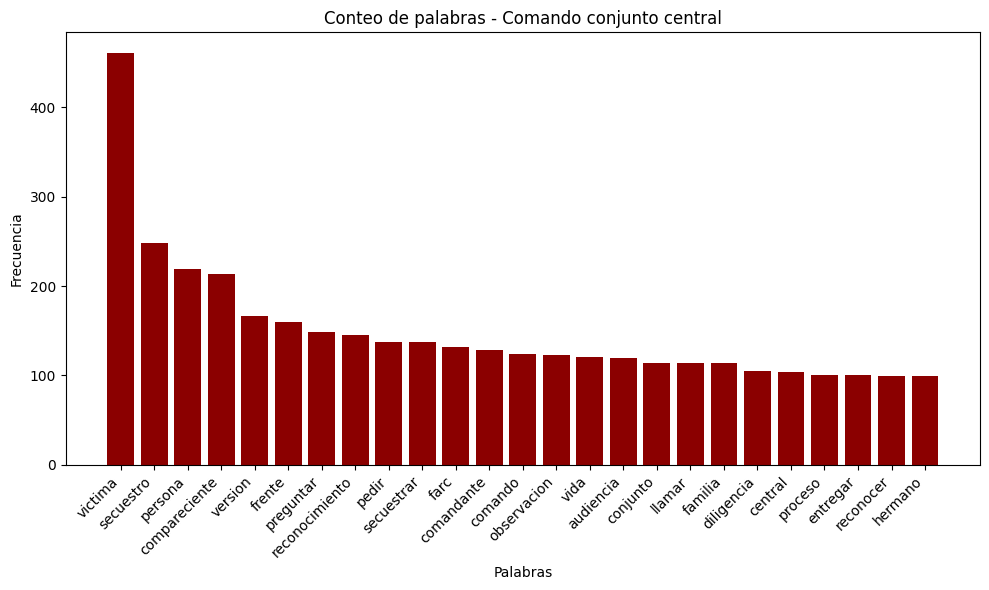

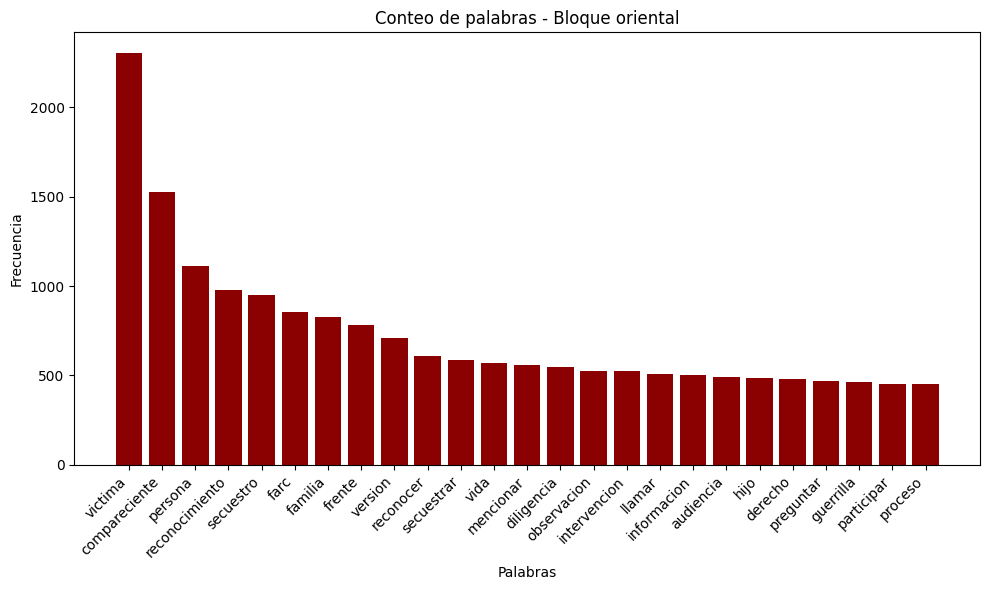

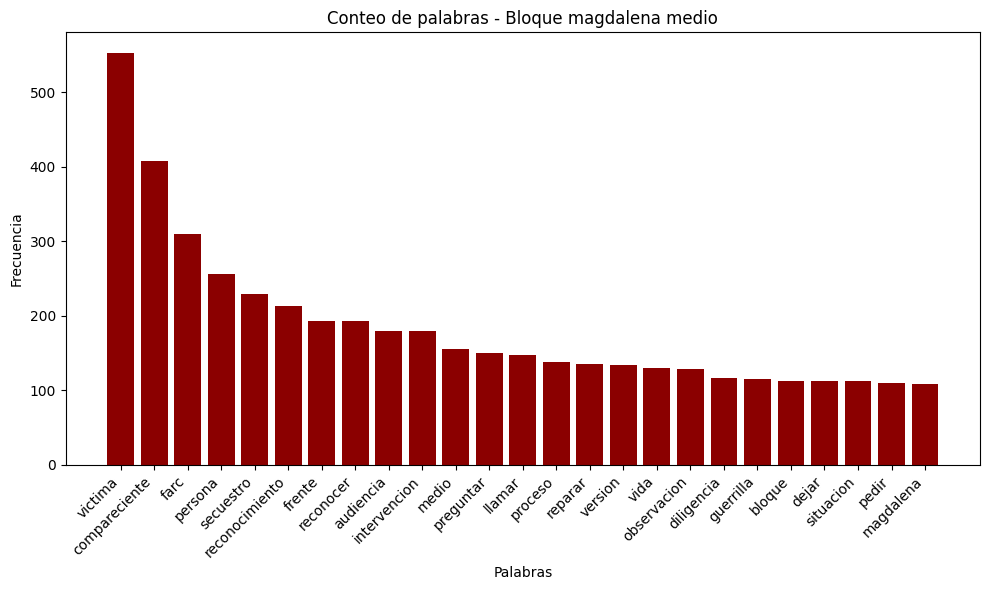

In [ ]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()

    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: Bloque Sur
           Palabra  Frecuencia
0          victima        2507
1          persona        1785
2    compareciente        1677
3        secuestro        1548
4             farc        1172
5   reconocimiento        1169
6          familia        1126
7             hijo        1044
8        reconocer         929
9        audiencia         910
10          frente         881
11         version         875
12            vida         870
13          llamar         765
14    jurisdiccion         764

 Frecuencias para: Bloque Caribe
           Palabra  Frecuencia
0          victima         947
1    compareciente         597
2          persona         472
3             farc         466
4        secuestro         387
5   reconocimiento         372
6           frente         298
7          version         282
8        reconocer         270
9          familia         256
10      diligencia         250
11           grupo         240
12            zona         230
13   

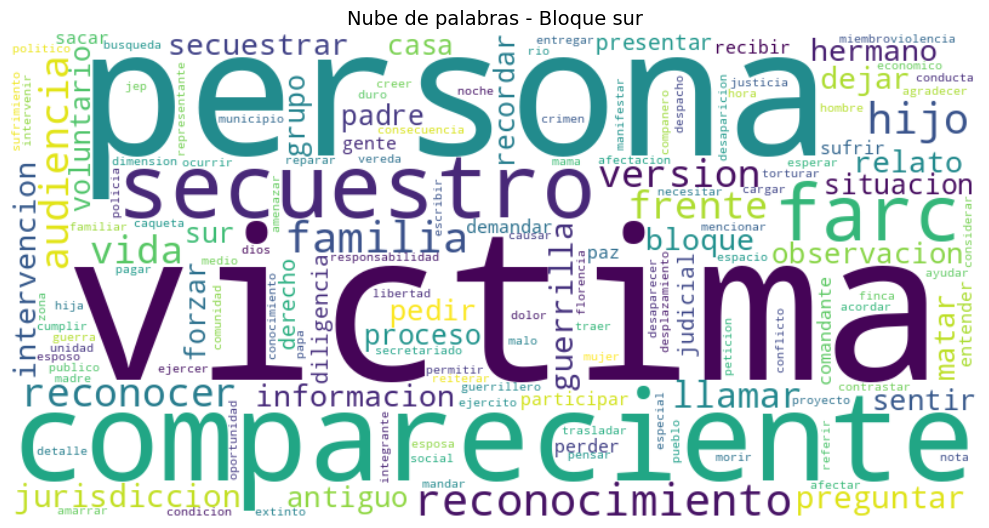

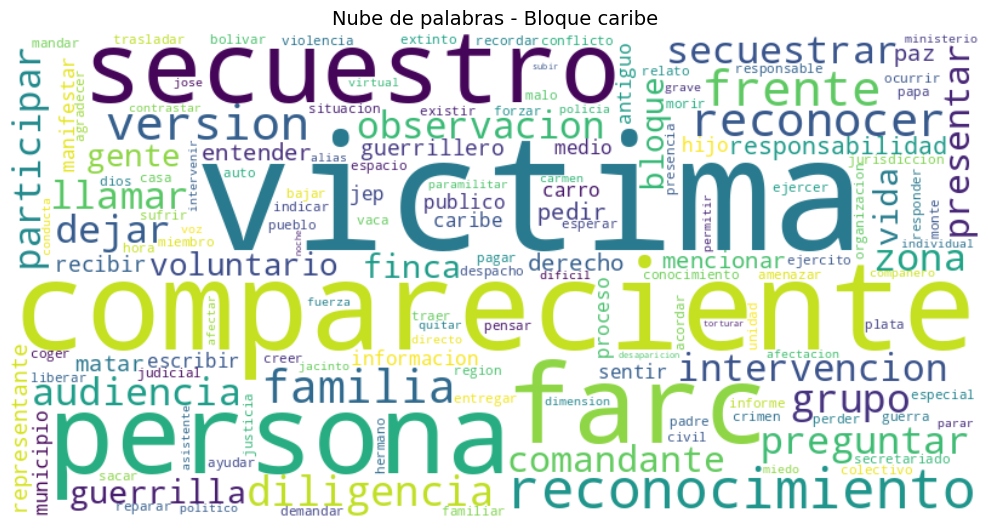

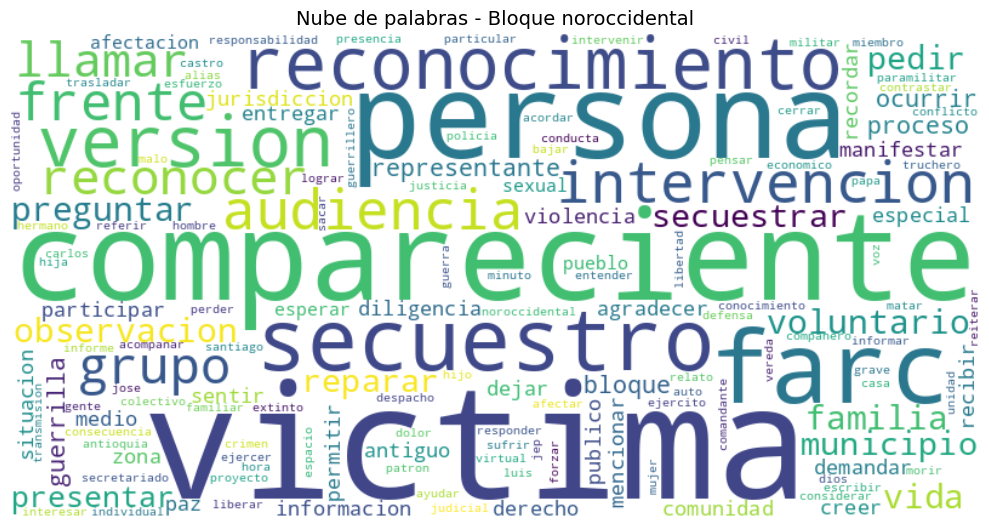

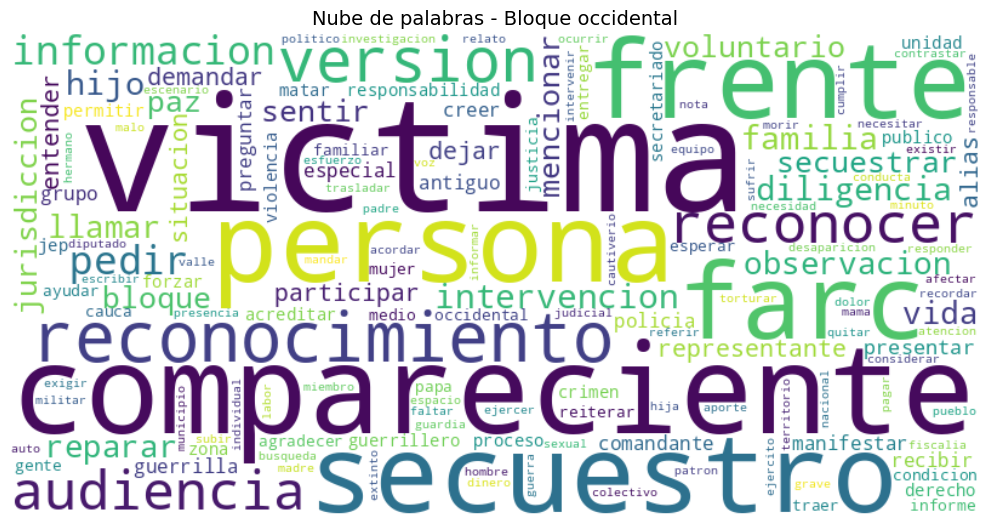

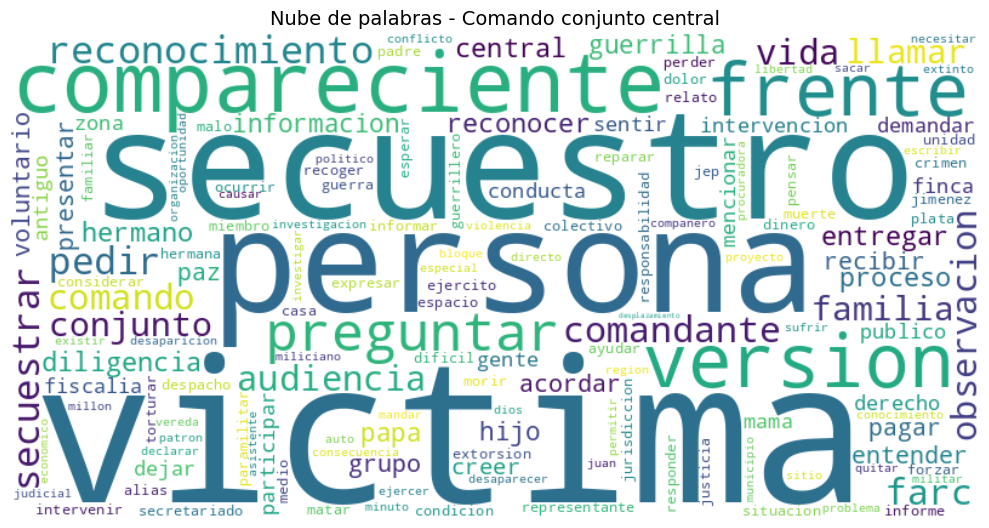

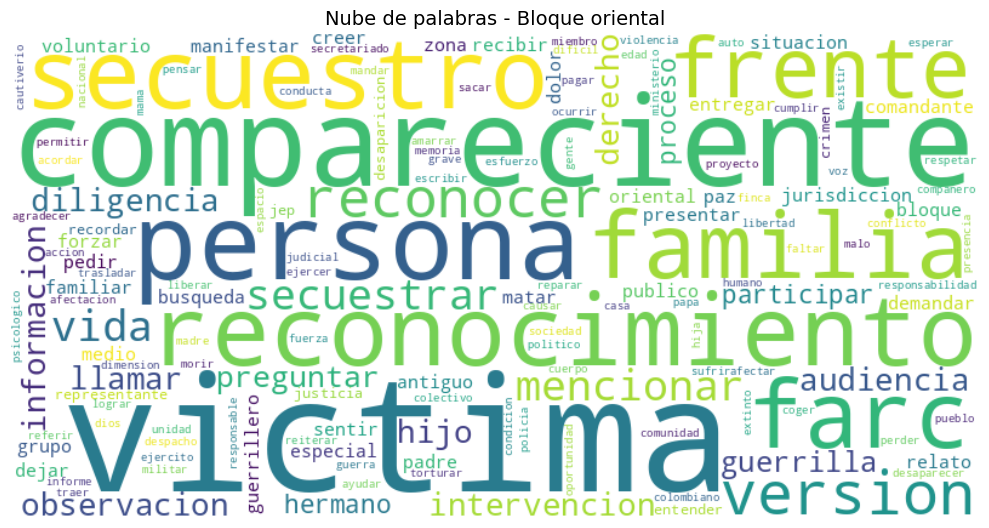

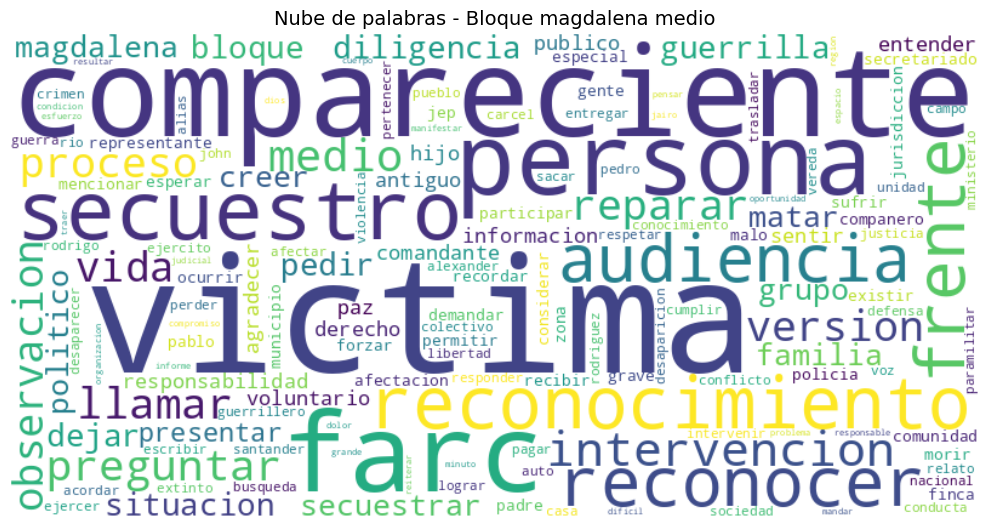

In [ ]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()


# **SIMILARIDAD LÉXICA ENTRE BLOQUES**

In [17]:
bloques = list(textos_skipgramas_filtrados.keys())
textos = [textos_skipgramas_filtrados[b]["texto_sin_stopwords"] for b in bloques]
vectorizer = TfidfVectorizer(ngram_range=(1, 2),min_df=2, sublinear_tf=True,norm="l2")
tfidf = vectorizer.fit_transform(textos)
similitud = cosine_similarity(tfidf) #similitud coseno
df_similitud = pd.DataFrame(similitud,index=bloques,columns=bloques)
df_similitud

,Bloque Sur,Bloque Caribe,Bloque Noroccidental,Bloque Occidental,Comando Conjunto Central,Bloque Oriental,Bloque Magdalena Medio
Bloque Sur,1.000000,0.526535,0.542103,0.461795,0.416630,0.713714,0.447004
Bloque Caribe,0.526535,1.000000,0.479984,0.438268,0.414329,0.532873,0.462882
Bloque Noroccidental,0.542103,0.479984,1.000000,0.472725,0.413812,0.528388,0.470588
Bloque Occidental,0.461795,0.438268,0.472725,1.000000,0.430742,0.456552,0.442487
Comando Conjunto Central,0.416630,0.414329,0.413812,0.430742,1.000000,0.412069,0.402704
Bloque Oriental,0.713714,0.532873,0.528388,0.456552,0.412069,1.000000,0.448259
Bloque Magdalena Medio,0.447004,0.462882,0.470588,0.442487,0.402704,0.448259,1.000000


# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())



                      Texto  Positivo  Negativo    Ira  Anticipación  \
0                Bloque Sur     29153     24275  12582         11225   
1             Bloque Caribe      7546      6581   3671          2761   
2      Bloque Noroccidental     12253     10620   5719          4868   
3         Bloque Occidental      5498      4544   2469          2138   
4  Comando Conjunto Central      3774      3155   1783          1407   

   Disgusto  Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0      6067  17873     7285     16560      7369      18636  
1      1404   4905     1723      4308      1889       4979  
2      2127   7744     3275      7111      2949       7687  
3      1014   3493     1283      3198      1248       3639  
4       720   2456      930      2221      1058       2583  


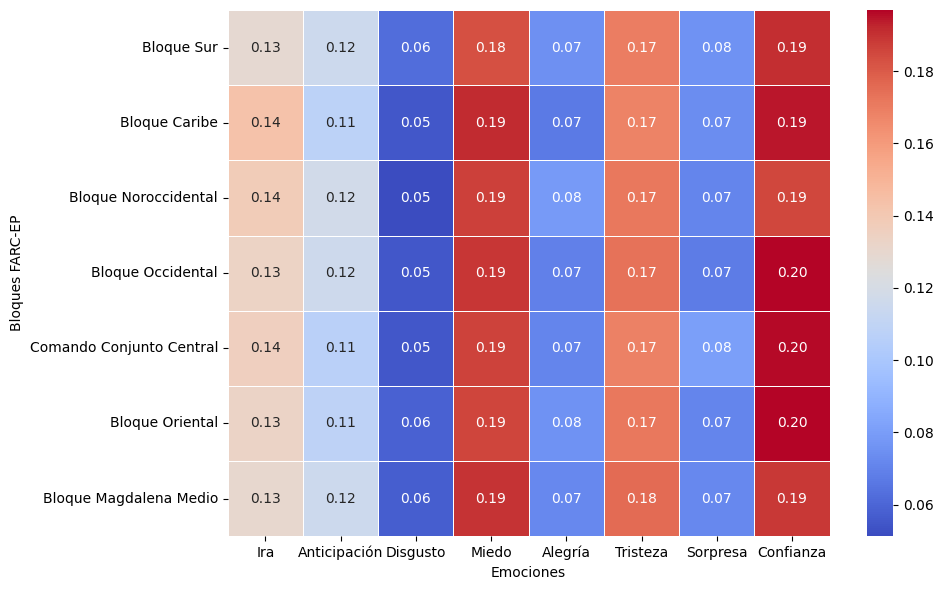

In [19]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Bloques FARC-EP')
plt.tight_layout()
plt.show()


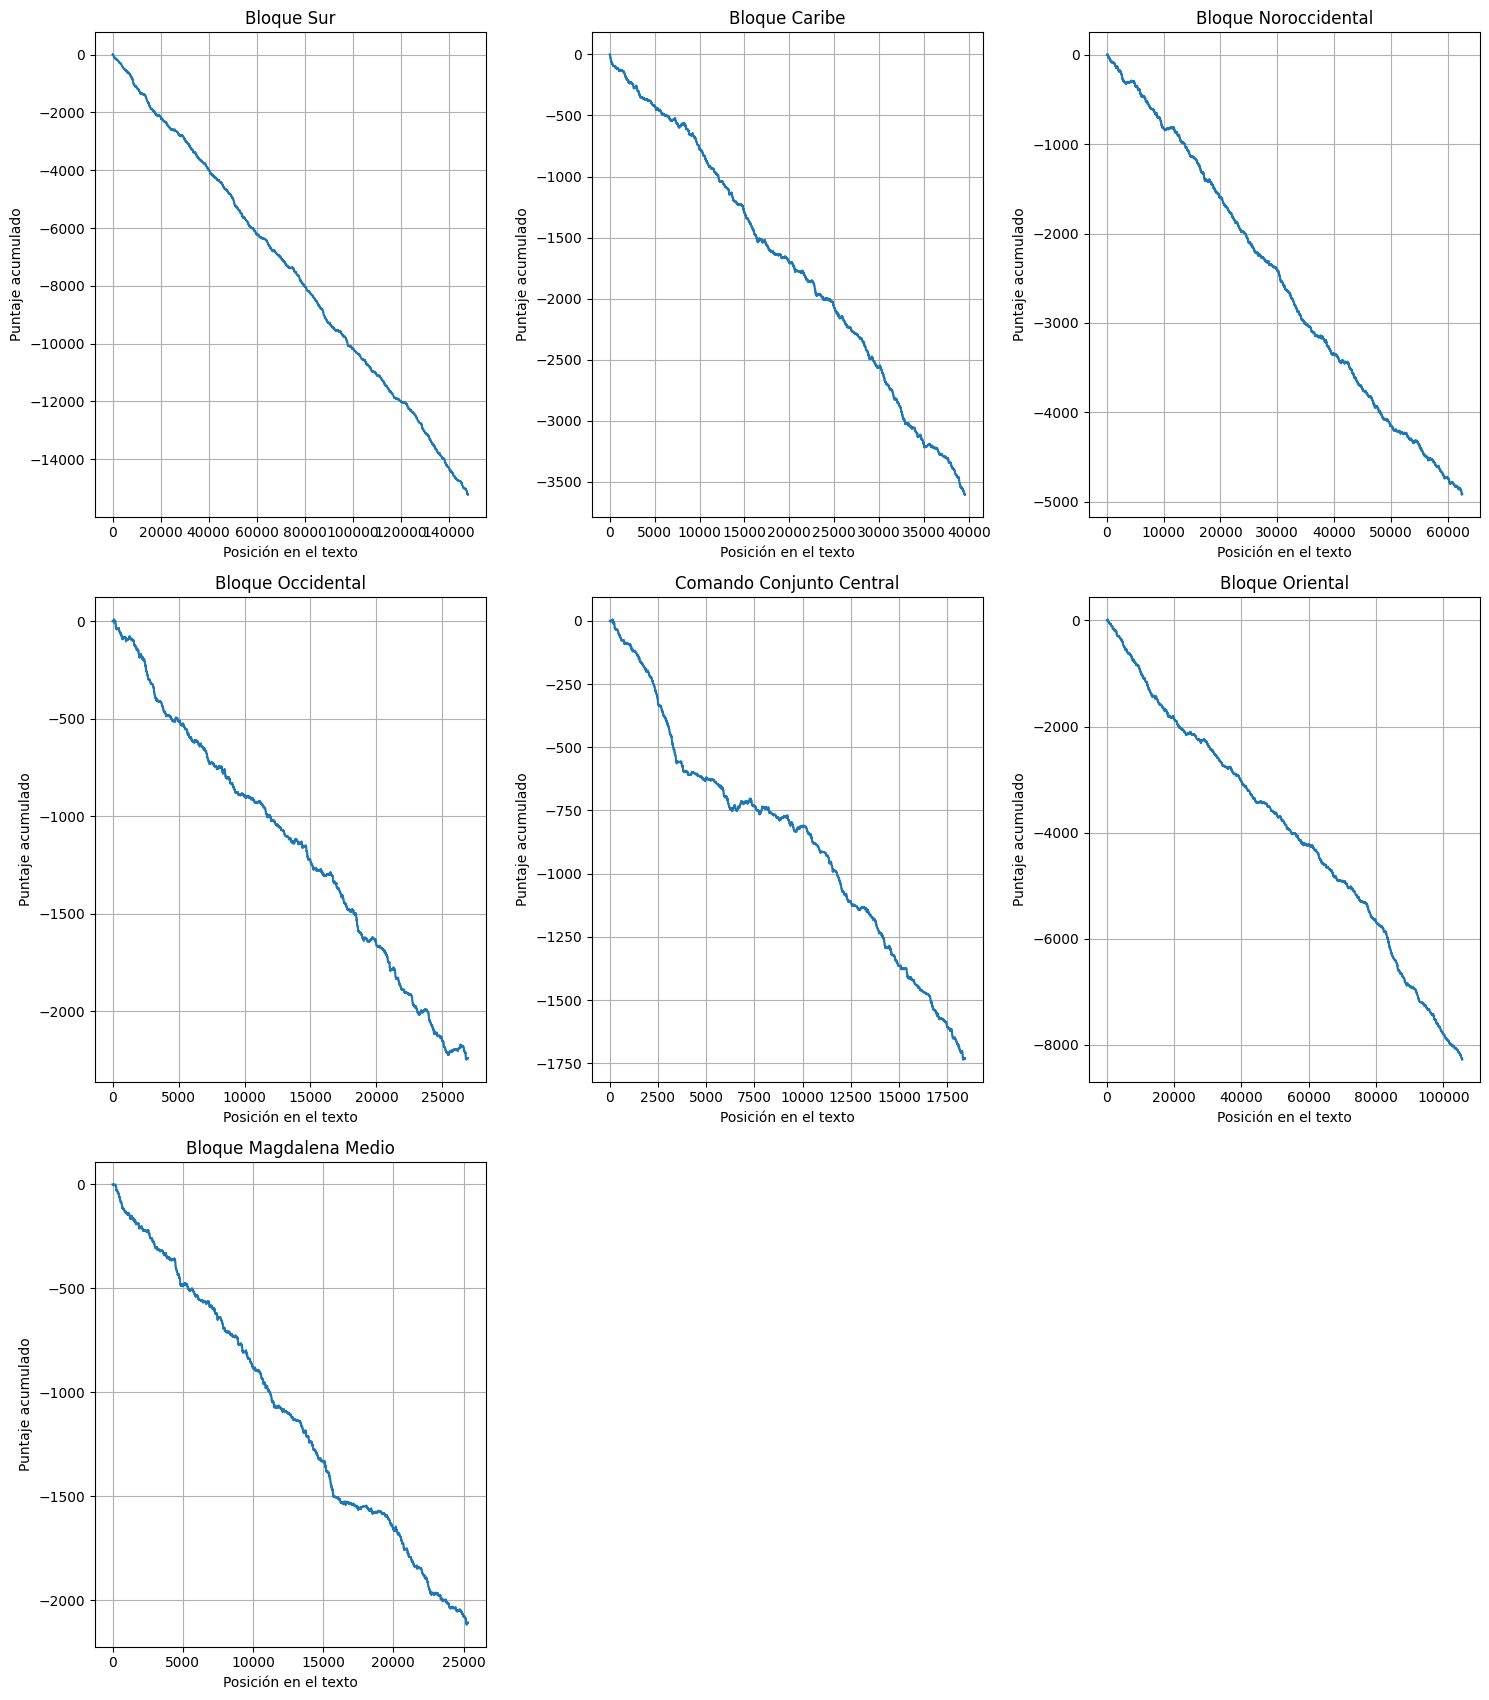

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")

afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

#grafico:
n = len(tendencias_afinn)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 6* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()





# **REDES**

In [21]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Bloque Sur': 3818 nodos, 55211 aristas (componente gigante).
Grafo 'Bloque Caribe': 1992 nodos, 14462 aristas (componente gigante).
Grafo 'Bloque Noroccidental': 2491 nodos, 27150 aristas (componente gigante).
Grafo 'Bloque Occidental': 1578 nodos, 10142 aristas (componente gigante).
Grafo 'Comando Conjunto Central': 1321 nodos, 7515 aristas (componente gigante).
Grafo 'Bloque Oriental': 3198 nodos, 34999 aristas (componente gigante).
Grafo 'Bloque Magdalena Medio': 1534 nodos, 9880 aristas (componente gigante).

Métricas
                          num_nodos  num_aristas  densidad  grado_promedio  \
Bloque Sur                     3818        55211  0.007577       28.921425   
Bloque Caribe                  1992        14462  0.007293       14.520080   
Bloque Noroccidental           2491        27150  0.008754       21.798475   
Bloque Occidental              1578        10142  0.008151       12.854246   
Comando Conjunto Central       1321         7515  0.008620       11.377744 

In [22]:
top10_grado_por_red

{'Bloque Sur':               nodo  grado  porcentaje_grado
 44         victima    997          0.009029
 25         persona    968          0.008766
 129      secuestro    808          0.007317
 45   compareciente    738          0.006683
 538        familia    728          0.006593
 137           farc    640          0.005796
 508           hijo    640          0.005796
 400           vida    585          0.005298
 207         frente    573          0.005189
 231      reconocer    565          0.005117,
 'Bloque Caribe':                nodo  grado  porcentaje_grado
 4           victima    569          0.019672
 86          persona    378          0.013069
 161   compareciente    366          0.012654
 51             farc    315          0.010891
 8         secuestro    278          0.009611
 112  reconocimiento    243          0.008401
 93          familia    228          0.007883
 183          frente    223          0.007710
 9             grupo    199          0.006880
 47          

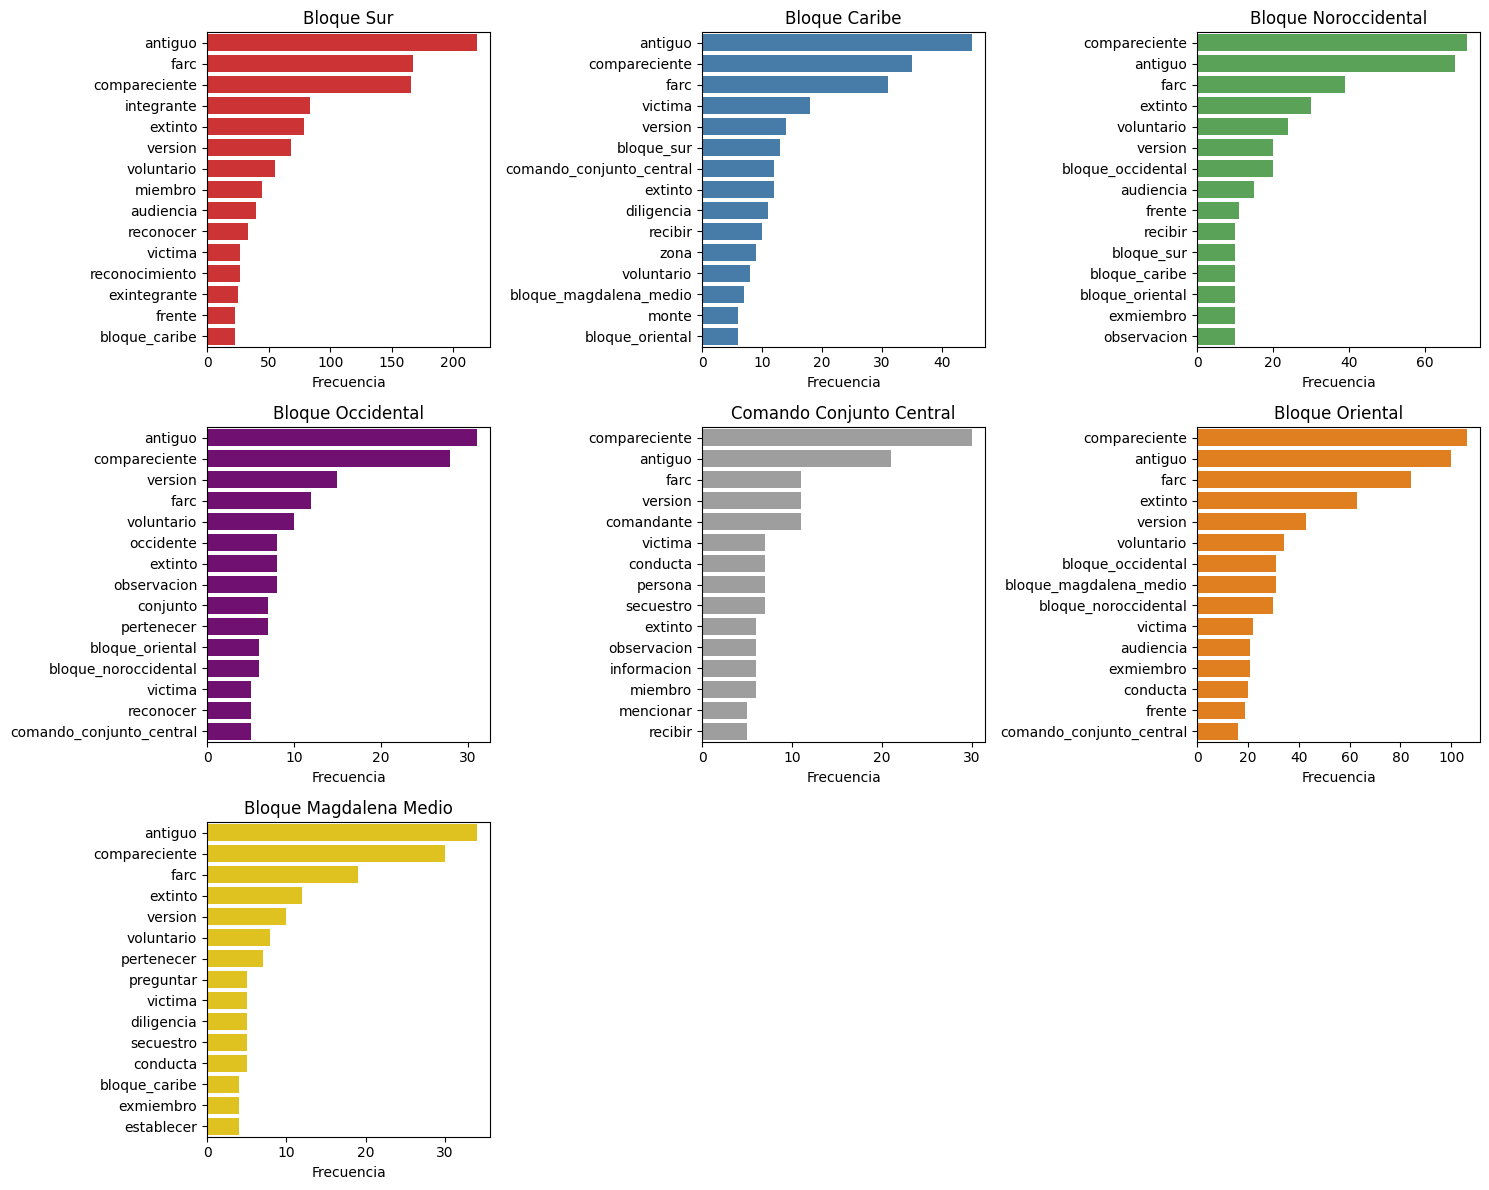

In [23]:
bloques = list(textos_skipgramas_filtrados.keys())
colores_bloques = {"Bloque Sur": "#e41a1c", "Bloque Caribe": "#377eb8","Bloque Noroccidental": "#4daf4a", "Bloque Central": "#984ea3",
    "Bloque Oriental": "#ff7f00", "Bloque Occidental": "purple","Bloque Magdalena Medio": "gold"}

tablas_bloques = {}

for bloque in bloques:
    texto = textos_skipgramas_filtrados[bloque]["texto_sin_stopwords"].lower()

    for b in bloques:
        base = b.lower().replace("bloque ", "")
        token = b.lower().replace(" ", "_")
        variantes = [
            b.lower(),
            base,
            f"bloque del {base}",
            f"bloque de {base}"
        ]
        for v in variantes:
            texto = re.sub(rf"\b{re.escape(v)}\b", token, texto)

    tokens = texto.split()
    skipgramas = [(tokens[i], tokens[j])
                  for i in range(len(tokens))
                  for j in range(i+1, min(i+3, len(tokens)))]

    token = bloque.lower().replace(" ", "_")
    conteo = Counter(v if u == token else u
                     for u, v in skipgramas
                     if token in (u, v))

    df = (pd.DataFrame(conteo.items(), columns=["palabra","frecuencia"])
            .sort_values("frecuencia", ascending=False)
            .head(15))

    tablas_bloques[bloque] = df

df_all = pd.concat([df.assign(bloque=b) for b, df in tablas_bloques.items()], ignore_index=True)

n_cols, n_rows = 3, math.ceil(len(bloques)/3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, bloque in enumerate(bloques):
    df = tablas_bloques[bloque]
    color = colores_bloques.get(bloque, "#9e9e9e")
    sns.barplot(x="frecuencia", y="palabra", data=df, ax=axes[i], color=color)
    axes[i].set_title(bloque)
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel("")

for ax in axes[len(bloques):]:
    ax.set_axis_off()
plt.tight_layout()
plt.show()